In [ ]:
!pip install -q timm albumentations lmdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 24.3 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import lmdb
import timm
import torch
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import defaultdict

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import albumentations as A
from albumentations.pytorch import ToTensorV2

from torch import nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r "/content/drive/MyDrive/deepfake_project/train.lmdb" /content/
!cp -r "/content/drive/MyDrive/deepfake_project/test.lmdb" /content/

In [ ]:
class CFG:

    IMG_SIZE = 224

    BATCH_SIZE = 8

    EPOCHS = 5

    LR = 1e-4

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    NUM_WORKERS = 2

    NUM_FRAMES = 8

    BASE_DIR = "/content/drive/MyDrive/deepfake_project"

    TRAIN_LMDB = "/content/train.lmdb"

    TEST_LMDB = "/content/test.lmdb"

print("Device:", CFG.DEVICE)

Device: cuda


In [ ]:
class VideoLMDBDataset(Dataset):

    def __init__(
        self,
        lmdb_path,
        transform=None,
        num_frames=8
    ):

        self.lmdb_path = lmdb_path

        self.transform = transform

        self.num_frames = num_frames

        env = lmdb.open(
            lmdb_path,
            readonly=True,
            lock=False,
            readahead=False,
            meminit=False,
            subdir=False
        )

        # ------------------------------------
        # GROUP ALL FRAMES BY VIDEO
        # ------------------------------------

        self.video_dict = defaultdict(list)

        with env.begin() as txn:

            cursor = txn.cursor()

            for key, value in cursor:

                sample = pickle.loads(value)

                video_id = sample["video_id"]

                label = int(sample["label"])

                self.video_dict[video_id].append({
                    "key": key,
                    "label": label
                })

        env.close()

        self.video_ids = list(self.video_dict.keys())

        self.labels = []

        for vid in self.video_ids:

            self.labels.append(
                self.video_dict[vid][0]["label"]
            )

        self.env = None
        self.txn = None

    def _init_db(self):

        if self.env is None:

            self.env = lmdb.open(
                self.lmdb_path,
                readonly=True,
                lock=False,
                readahead=False,
                meminit=False,
                subdir=False
            )

            self.txn = self.env.begin()

    def __len__(self):

        return len(self.video_ids)

    def __getitem__(self, idx):

        self._init_db()

        video_id = self.video_ids[idx]

        samples = self.video_dict[video_id]

        label = samples[0]["label"]

        # ------------------------------------
        # SAMPLE FRAMES
        # ------------------------------------

        if len(samples) >= self.num_frames:

            selected = random.sample(
                samples,
                self.num_frames
            )

        else:

            selected = random.choices(
                samples,
                k=self.num_frames
            )

        frames = []

        for item in selected:

            value = self.txn.get(item["key"])

            sample = pickle.loads(value)

            img = np.frombuffer(
                sample["image"],
                np.uint8
            )

            img = cv2.imdecode(
                img,
                cv2.IMREAD_COLOR
            )

            img = cv2.cvtColor(
                img,
                cv2.COLOR_BGR2RGB
            )

            if self.transform:

                img = self.transform(
                    image=img
                )["image"]

            frames.append(img)

        # ------------------------------------
        # [T, C, H, W]
        # ------------------------------------

        frames = torch.stack(frames)

        return {
            "frames": frames,
            "label": torch.tensor(
                label,
                dtype=torch.float32
            ),
            "video_id": video_id
        }


In [ ]:
train_transform = A.Compose([

    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),

    A.HorizontalFlip(p=0.5),

    A.RandomBrightnessContrast(p=0.5),

    A.ImageCompression(
        quality_range=(60, 100),
        p=0.5
    ),

    A.GaussianBlur(p=0.3),

    A.Normalize(),

    ToTensorV2()
])

valid_transform = A.Compose([

    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),

    A.Normalize(),

    ToTensorV2()
])

In [ ]:
class TrueLateFusionModel(nn.Module):

    def __init__(self):

        super().__init__()

        # ------------------------------------
        # CNN BACKBONE
        # ------------------------------------

        self.backbone = timm.create_model(

            "tf_efficientnetv2_b0",

            pretrained=True,

            num_classes=0,

            global_pool="avg"
        )

        feat_dim = self.backbone.num_features

        # ------------------------------------
        # VIDEO-LEVEL CLASSIFIER
        # ------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(feat_dim, 512),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(512, 128),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(128, 1)
        )

    def forward(self, x):

        # ------------------------------------
        # x = [B, T, C, H, W]
        # ------------------------------------

        B, T, C, H, W = x.shape

        # ------------------------------------
        # MERGE TEMPORAL DIMENSION
        # ------------------------------------

        x = x.view(B * T, C, H, W)

        # ------------------------------------
        # FRAME FEATURES
        # ------------------------------------

        features = self.backbone(x)

        # ------------------------------------
        # [B*T, F] -> [B, T, F]
        # ------------------------------------

        features = features.view(
            B,
            T,
            -1
        )

        # ------------------------------------
        # TRUE LATE FUSION
        # ------------------------------------
        #
        # MEAN POOL ACROSS FRAMES
        #
        # [B, T, F] -> [B, F]
        #
        # ------------------------------------

        fused = features.mean(dim=1)

        # ------------------------------------
        # VIDEO PREDICTION
        # ------------------------------------

        logits = self.classifier(fused)

        logits = logits.squeeze(1)

        return logits

In [ ]:
train_dataset = VideoLMDBDataset(

    CFG.TRAIN_LMDB,

    transform=train_transform,

    num_frames=CFG.NUM_FRAMES
)

test_dataset = VideoLMDBDataset(

    CFG.TEST_LMDB,

    transform=valid_transform,

    num_frames=CFG.NUM_FRAMES
)

In [ ]:
train_loader = DataLoader(

    train_dataset,

    batch_size=CFG.BATCH_SIZE,

    shuffle=True,

    num_workers=CFG.NUM_WORKERS,

    pin_memory=True
)

test_loader = DataLoader(

    test_dataset,

    batch_size=CFG.BATCH_SIZE,

    shuffle=False,

    num_workers=CFG.NUM_WORKERS,

    pin_memory=True
)

print("Train videos:", len(train_dataset))
print("Test videos :", len(test_dataset))

Train videos: 937
Test videos : 235


In [ ]:
model = TrueLateFusionModel().to(CFG.DEVICE)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.LR
)

scaler = torch.cuda.amp.GradScaler()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/28.8M [00:00<?, ?B/s]

/tmp/ipykernel_8404/2639707726.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_auc": []
}

In [ ]:
def train_one_epoch():

    model.train()

    total_loss = 0

    all_preds = []
    all_labels = []

    for batch in tqdm(train_loader):

        frames = batch["frames"].to(CFG.DEVICE)

        labels = batch["label"].to(CFG.DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            logits = model(frames)

            loss = criterion(
                logits,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        total_loss += loss.item()

        probs = torch.sigmoid(logits)

        preds = (probs > 0.5).float()

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    return total_loss / len(train_loader), acc

In [ ]:
def evaluate():

    model.eval()

    probs_list = []
    preds_list = []
    labels_list = []
    vids_list = []

    with torch.no_grad():

        for batch in tqdm(test_loader):

            frames = batch["frames"].to(CFG.DEVICE)

            labels = batch["label"].to(CFG.DEVICE)

            vids = batch["video_id"]

            with torch.cuda.amp.autocast():

                logits = model(frames)

            probs = torch.sigmoid(logits)

            preds = (probs > 0.5).float()

            probs_list.extend(
                probs.cpu().numpy()
            )

            preds_list.extend(
                preds.cpu().numpy()
            )

            labels_list.extend(
                labels.cpu().numpy()
            )

            vids_list.extend(vids)

    acc = accuracy_score(
        labels_list,
        preds_list
    )

    prec = precision_score(
        labels_list,
        preds_list
    )

    rec = recall_score(
        labels_list,
        preds_list
    )

    f1 = f1_score(
        labels_list,
        preds_list
    )

    auc = roc_auc_score(
        labels_list,
        probs_list
    )

    return (
        acc,
        prec,
        rec,
        f1,
        auc,
        probs_list,
        preds_list,
        labels_list,
        vids_list
    )

In [ ]:
best_auc = 0

for epoch in range(CFG.EPOCHS):

    print(f"\nEpoch {epoch+1}/{CFG.EPOCHS}")

    train_loss, train_acc = train_one_epoch()

    val_acc, prec, rec, f1, auc, probs, labels, vids = evaluate()

    history["train_loss"].append(train_loss)

    history["train_acc"].append(train_acc)

    history["val_acc"].append(val_acc)

    history["val_auc"].append(auc)

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Train Acc : {train_acc:.4f}")

    print(f"Val Acc   : {val_acc:.4f}")

    print(f"Precision : {prec:.4f}")

    print(f"Recall    : {rec:.4f}")

    print(f"F1        : {f1:.4f}")

    print(f"AUC       : {auc:.4f}")

    if auc > best_auc:

        best_auc = auc

        torch.save(
            model.state_dict(),
            "/content/best_true_late_fusion.pth"
        )

        print("Best model saved.")


Epoch 1/5


  0%|          | 0/118 [00:00<?, ?it/s]/tmp/ipykernel_8404/2607096272.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
  0%|          | 0/30 [00:00<?, ?it/s]/tmp/ipykernel_8404/1578343103.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 30/30 [00:04<00:00,  6.22it/s]


Train Loss: 0.3912
Train Acc : 0.8378
Val Acc   : 0.9447
Precision : 0.8286
Recall    : 0.8056
F1        : 0.8169
AUC       : 0.9757
Best model saved.

Epoch 2/5


  0%|          | 0/118 [00:00<?, ?it/s]/tmp/ipykernel_8404/2607096272.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
  0%|          | 0/30 [00:00<?, ?it/s]/tmp/ipykernel_8404/1578343103.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 30/30 [00:02<00:00, 10.54it/s]


Train Loss: 0.1485
Train Acc : 0.9509
Val Acc   : 0.9702
Precision : 0.9143
Recall    : 0.8889
F1        : 0.9014
AUC       : 0.9933
Best model saved.

Epoch 3/5


...

Train Loss: 0.0714
Train Acc : 0.9765
Val Acc   : 0.9574
Precision : 0.8421
Recall    : 0.8889
F1        : 0.8649
AUC       : 0.9862

Epoch 4/5


  0%|          | 0/118 [00:00<?, ?it/s]/tmp/ipykernel_8404/2607096272.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
  0%|          | 0/30 [00:00<?, ?it/s]/tmp/ipykernel_8404/1578343103.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 30/30 [00:02<00:00, 10.84it/s]


Train Loss: 0.0819
Train Acc : 0.9733
Val Acc   : 0.9745
Precision : 0.9167
Recall    : 0.9167
F1        : 0.9167
AUC       : 0.9965
Best model saved.

Epoch 5/5


  0%|          | 0/118 [00:00<?, ?it/s]/tmp/ipykernel_8404/2607096272.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
  0%|          | 0/30 [00:00<?, ?it/s]/tmp/ipykernel_8404/1578343103.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 30/30 [00:03<00:00,  8.55it/s]

Train Loss: 0.0446
Train Acc : 0.9840
Val Acc   : 0.9277
Precision : 0.6863
Recall    : 0.9722
F1        : 0.8046
AUC       : 0.9939


In [ ]:
!cp /content/best_true_late_fusion.pth "/content/drive/MyDrive/deepfake_project/"

In [ ]:
!ls -lah "/content/drive/MyDrive/deepfake_project/"

total 452M
-rw------- 1 root root  26M May 27 17:24 best_late_fusion.pth
-rw------- 1 root root  23M May 25 13:46 best_model.pth
-rw------- 1 root root  26M May 27 18:18 best_true_late_fusion.pth
drwx------ 2 root root 4.0K May 19 12:37 data
drwx------ 2 root root 4.0K May 19 14:28 notebooks
drwx------ 2 root root 4.0K May 19 14:28 outputs
drwx------ 2 root root 4.0K May 19 14:29 src
-rw------- 1 root root  76M May 23 22:06 test.lmdb
-rw------- 1 root root 303M May 23 22:06 train.lmdb


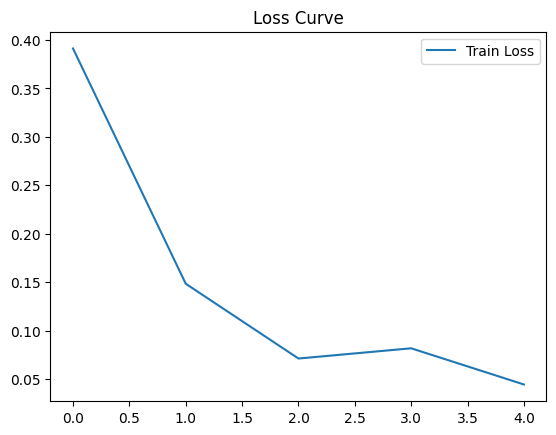

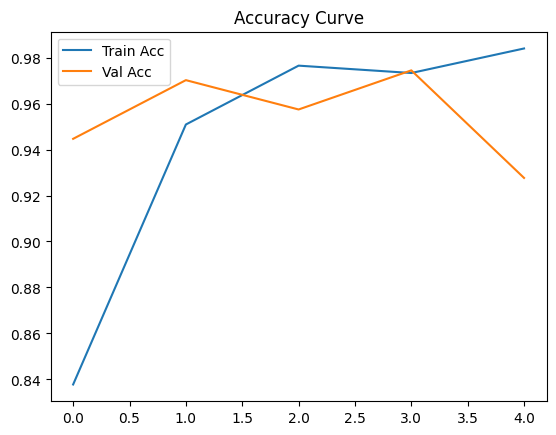

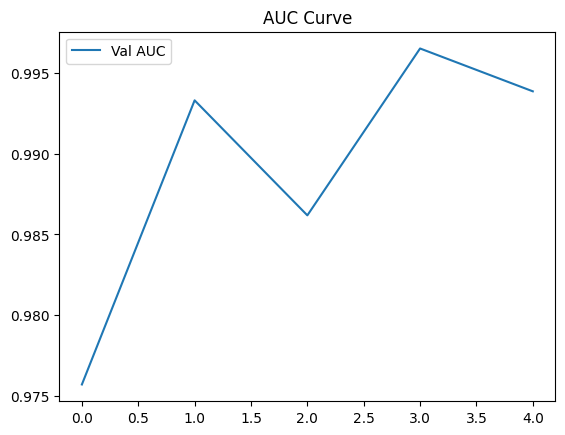

In [ ]:
plt.figure()

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.title("Loss Curve")

plt.legend()

plt.show()

plt.figure()

plt.plot(
    history["train_acc"],
    label="Train Acc"
)

plt.plot(
    history["val_acc"],
    label="Val Acc"
)

plt.title("Accuracy Curve")

plt.legend()

plt.show()

plt.figure()

plt.plot(
    history["val_auc"],
    label="Val AUC"
)

plt.title("AUC Curve")

plt.legend()

plt.show()


In [ ]:
print("\n===================================")
print("FINAL VIDEO-LEVEL RESULTS")
print("===================================")

model.load_state_dict(
    torch.load(
        "/content/best_true_late_fusion.pth"
    )
)

metrics = evaluate()

acc         = metrics[0]
prec        = metrics[1]
rec         = metrics[2]
f1          = metrics[3]
auc         = metrics[4]
probs_list  = metrics[5]
preds_list  = metrics[6]
labels_list = metrics[7]

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")


FINAL VIDEO-LEVEL RESULTS


  0%|          | 0/30 [00:00<?, ?it/s]/tmp/ipykernel_8404/4225656053.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 30/30 [00:03<00:00,  8.77it/s]

Accuracy : 0.9745
Precision: 0.9167
Recall   : 0.9167
F1 Score : 0.9167
ROC-AUC  : 0.9943


In [ ]:
print("\nClassification Report:\n")

print(
    classification_report(
        labels_list,
        preds_list,
        digits=4
    )
)



Classification Report:

              precision    recall  f1-score   support

         0.0     0.9849    0.9849    0.9849       199
         1.0     0.9167    0.9167    0.9167        36

    accuracy                         0.9745       235
   macro avg     0.9508    0.9508    0.9508       235
weighted avg     0.9745    0.9745    0.9745       235



In [ ]:
cm = confusion_matrix(
    labels_list,
    preds_list
)

print("\nConfusion Matrix:\n")
print(cm)

print("\nDone.")


Confusion Matrix:

[[196   3]
 [  3  33]]

Done.
